In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [ ]:
df = pd.read_csv('data/to_use/participant_info.csv', encoding='utf-8-sig')

/Users/sonia/Documents/SYEP


/Applications/Positron.app/Contents/Resources/app/extensions/positron-python/python_files/lib/ipykernel/py3/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
<positron-console-cell-3>:3: DtypeWarning: Columns (0: Date.DeEnrolled, 1: Special.Project) have mixed types. Specify dtype option on import or set low_memory=False.


In [4]:
sns.set_theme(style="whitegrid", palette=["steelblue"])

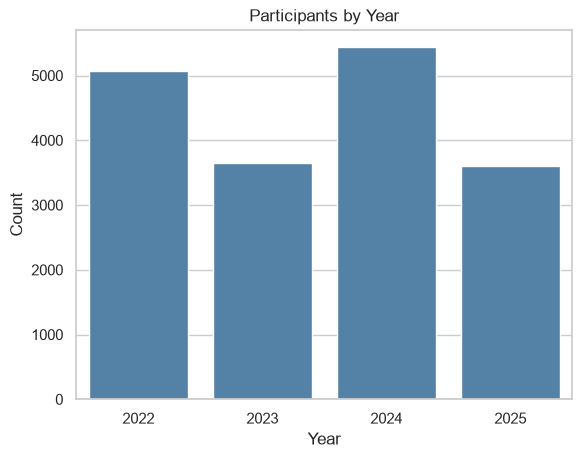

In [90]:
ax = sns.countplot(x="Year", data=df)
ax.set_ylabel("Count")
ax.set_title("Participants by Year")
plt.savefig('plots/desc/by_year.png')
plt.show()

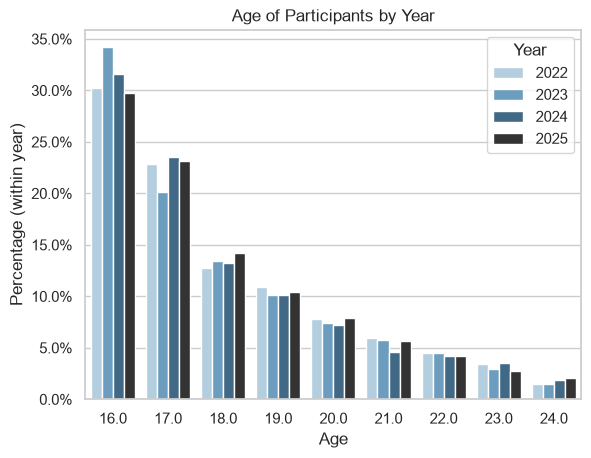

In [21]:
df_pct = (df.groupby('Year')['Age.on.Start.Date']
            .value_counts(normalize=True)
            .rename('Percent')
            .mul(100)
            .reset_index())

ax = sns.barplot(
    data=df_pct,
    x="Age.on.Start.Date",
    y="Percent",
    hue="Year",
    palette="Blues_d",
)

ax.set_xlabel('Age')
ax.set_ylabel('Percentage (within year)')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())
ax.set_title("Age of Participants by Year")
plt.savefig('plots/desc/pct_age_by_year.png')
plt.show()

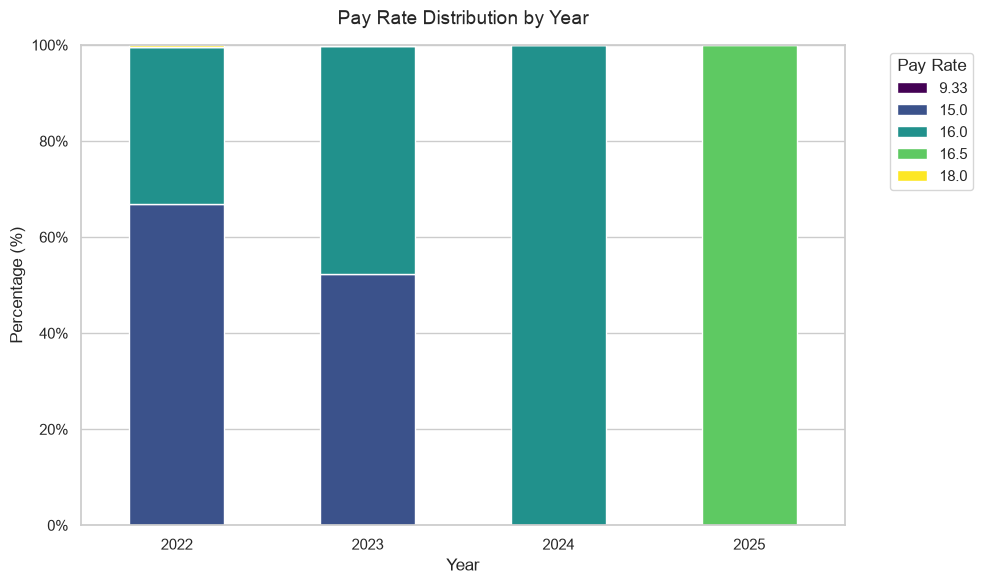

In [101]:
df_pct = (
    df.groupby('Year')['Pay.Rate']
    .value_counts(normalize=True)
    .rename('Percent')
    .mul(100)
    .reset_index()
)

df_pivot = df_pct.pivot(index='Year', columns='Pay.Rate', values='Percent')

ax = df_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='viridis',
    edgecolor='white', 
)

ax.set_title('Pay Rate Distribution by Year', fontsize=14, pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())

plt.xticks(rotation=0)
plt.legend(title='Pay Rate', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('plots/desc/pct_age_by_year_stacked.png')
plt.show()

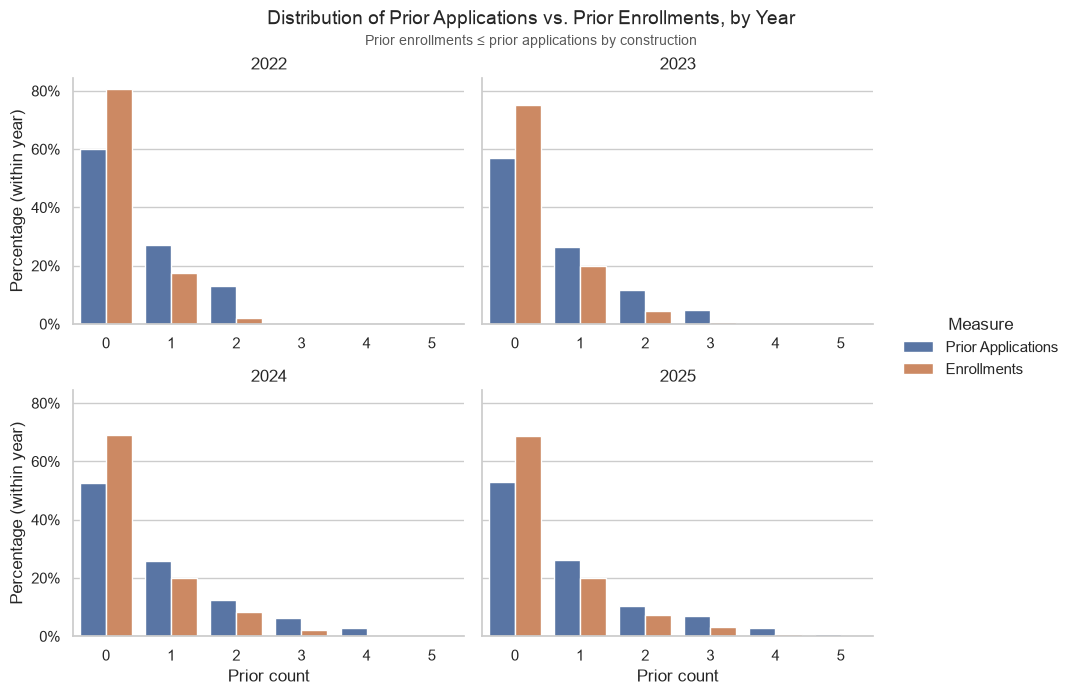

In [26]:
df_pct = (
    df.melt(
        id_vars='Year',
        value_vars=['n_prior_apps', 'n_prior_enroll'],
        var_name='Measure',
        value_name='Count',
    )
    .groupby(['Year', 'Measure'])['Count']
    .value_counts(normalize=True)
    .rename('Percent')
    .mul(100)
    .reset_index()
    .replace({'Measure': {'n_prior_apps': 'Prior Applications',
                          'n_prior_enroll': 'Enrollments'}})
)

g = sns.catplot(
    data=df_pct,
    x='Count', y='Percent', hue='Measure',
    col='Year', col_wrap=2, kind='bar',
    palette=['#4c72b0', '#dd8452'],
    height=3.5, aspect=1.3,
)
g.figure.suptitle('Distribution of Prior Applications vs. Prior Enrollments, by Year',
                  fontsize=14, y=0.99)
g.figure.text(0.5, 0.94,
              'Prior enrollments ≤ prior applications by construction',
              ha='center', fontsize=10, color='0.35')
g.figure.subplots_adjust(top=0.88)
g.set_axis_labels('Prior count', 'Percentage (within year)')
g.set_axis_labels('Prior count', 'Percentage (within year)')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)
    ax.set_xlabel('Prior count')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())
g.tight_layout()
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())
g.savefig('plots/desc/pct_apps_enr_within_year.png', dpi=150)
plt.show()